# Linear Soft-Margin SVM (Primal) — SGD from Scratch

This notebook implements a **linear Support Vector Machine** using only NumPy for
the model and optimizer.

## Primal soft-margin formulation (convex)

$$\min_{w,\,b,\,\xi}\;\frac{1}{2}\|w\|^2 + C\sum_i \xi_i
\quad\text{s.t.}\quad
y_i(w^\top x_i + b) \ge 1 - \xi_i,\; \xi_i \ge 0$$

Eliminating slack variables via $\xi_i = \max(0, 1 - y_i(w^\top x_i + b))$ gives
the unconstrained **hinge-loss** objective:

$$J(w,b) = \frac{\lambda}{2}\|w\|^2 + C\sum_i \max\!\left(0,\,1 - y_i(w^\top x_i + b)\right)$$

### KKT intuition — why "support vectors" matter

| Region                                    | Hinge loss | Dual multiplier    |
|-------------------------------------------|------------|--------------------|
| $y_i f(x_i) > 1$ (outside margin)         | 0          | $\alpha_i = 0$     |
| $y_i f(x_i) = 1$ (on margin)              | 0          | $0 < \alpha_i < C$ |
| $y_i f(x_i) < 1$ (inside / misclassified) | active     | $\alpha_i = C$     |

Only points **on or inside** the margin influence the solution — they are the **support vectors**.


## 1 · Imports

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

FloatArray = NDArray[np.float64]
IntArray   = NDArray[np.int64]

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

# Robust project root detection: walk ancestors and pick the first directory
# that contains either the processed data file or a README.md (heuristic).
def find_project_root(start: Path = Path.cwd()):
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "data" / "processed" / "clean_student_data.csv").exists():
            return p
        if (p / "README.md").exists():
            return p
    return start

PROJECT_ROOT = find_project_root()
print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\Elodie\DataspellProjects\Convex-Optimization


## 2 · `FitReport` — training summary dataclass

In [2]:
@dataclass(frozen=True)
class FitReport:
    """Summary returned by `LinearSVM.fit`."""
    n_epochs: int
    converged: bool
    final_loss: float
    best_val_accuracy: Optional[float]
    best_val_f1: Optional[float]


## 3 · `LinearSVM` class

The class is split across several cells for readability:
1. `__init__` — hyperparameters & state
2. `fit` — SGD training loop
3. Inference — `decision_function`, `predict`, `score`
4. Threshold tuning — `tune_decision_threshold`
5. Internal helpers


### 3.1 `__init__`

In [3]:
class LinearSVM:
    r"""Linear soft-margin SVM classifier trained with SGD."""

    _CONVERGENCE_TOL: float = 1e-4
    _CONVERGENCE_PATIENCE: int = 5

    def __init__(
        self,
        learning_rate: float = 1e-5,
        lambda_param: float = 10.0,
        n_iters: int = 1000,
        C: float = 0.5,
        class_weight: dict[int, float] | str | None = {-1: 2.0, 1: 1.0},
        decay_rate: float = 0.01,
    ) -> None:
        if learning_rate <= 0: raise ValueError("learning_rate must be > 0")
        if lambda_param  <= 0: raise ValueError("lambda_param must be > 0")
        if n_iters       <= 0: raise ValueError("n_iters must be > 0")
        if C             <= 0: raise ValueError("C must be > 0")
        if decay_rate    <  0: raise ValueError("decay_rate must be >= 0")

        self.learning_rate = float(learning_rate)
        self.lambda_param  = float(lambda_param)
        self.n_iters       = int(n_iters)
        self.C             = float(C)
        self.class_weight  = class_weight
        self.decay_rate    = float(decay_rate)

        self.class_weight_: Optional[dict[int, float]] = None
        self.w_: Optional[FloatArray] = None
        self.b_: float = 0.0
        self.decision_threshold_: float = 0.5

        self.loss_history_:           list[float] = []
        self.train_accuracy_history_: list[float] = []
        self.val_accuracy_history_:   list[float] = []
        self.train_f1_history_:       list[float] = []
        self.val_f1_history_:         list[float] = []

        self.converged_: bool = False
        self.n_epochs_:  int  = 0


### 3.2 `fit` — SGD training loop

In [4]:
def fit(
    self,
    X: NDArray[np.floating],
    y: NDArray[np.integer] | NDArray[np.floating],
    X_val: Optional[NDArray[np.floating]] = None,
    y_val: Optional[NDArray[np.integer] | NDArray[np.floating]] = None,
    *,
    shuffle: bool = True,
    random_state: Optional[int] = 42,
    verbose: bool = False,
) -> FitReport:
    """Fit the SVM model using SGD."""
    X_train, y_train = self._validate_X_y(X, y, require_both_classes=True)
    self.class_weight_ = self._resolve_class_weight(y_train)

    X_val_arr: Optional[FloatArray] = None
    y_val_arr: Optional[IntArray]   = None
    if (X_val is None) ^ (y_val is None):
        raise ValueError("Provide both X_val and y_val, or neither")
    if X_val is not None and y_val is not None:
        X_val_arr, y_val_arr = self._validate_X_y(X_val, y_val, require_both_classes=False)

    n_samples, n_features = X_train.shape
    w   = np.zeros(n_features, dtype=np.float64)
    b   = 0.0
    lr, lam, C = self.learning_rate, self.lambda_param, self.C

    w_neg    = self.class_weight_[-1]
    w_pos    = self.class_weight_[1]
    sample_C = C * np.where(y_train == 1, w_pos, w_neg).astype(np.float64)

    rng = np.random.default_rng(random_state)

    # Reset histories
    for history in (self.loss_history_, self.train_accuracy_history_,
                    self.val_accuracy_history_, self.train_f1_history_, self.val_f1_history_):
        history.clear()

    best_val_acc, best_val_f1 = None, None
    no_improve_count = 0
    prev_loss        = None
    self.converged_  = False

    for epoch in range(self.n_iters):
        indices    = rng.permutation(n_samples) if shuffle else np.arange(n_samples)
        current_lr = lr / (1.0 + self.decay_rate * epoch)

        # SGD inner loop
        for idx in indices:
            x_i = X_train[idx]
            y_i = float(y_train[idx])
            C_i = float(sample_C[idx])

            margin = y_i * (np.dot(x_i, w) + b)
            if margin >= 1.0:
                w -= current_lr * (lam * w)
            else:
                w -= current_lr * (lam * w - C_i * y_i * x_i)
                b += current_lr * (C_i * y_i)

        # End-of-epoch metrics (compute scores once)
        train_scores = self.decision_function(X_train, w, b)
        epoch_loss   = self._primal_objective(train_scores, y_train, w, sample_C=sample_C)
        self.loss_history_.append(epoch_loss)

        train_acc, train_f1 = self._metrics_from_scores(train_scores, y_train)
        self.train_accuracy_history_.append(train_acc)
        self.train_f1_history_.append(train_f1)

        if X_val_arr is not None and y_val_arr is not None:
            val_scores          = self.decision_function(X_val_arr, w, b)
            val_acc, val_f1     = self._metrics_from_scores(val_scores, y_val_arr)
            self.val_accuracy_history_.append(val_acc)
            self.val_f1_history_.append(val_f1)
            best_val_acc = val_acc if best_val_acc is None else max(best_val_acc, val_acc)
            best_val_f1  = val_f1  if best_val_f1  is None else max(best_val_f1,  val_f1)

        # Convergence check
        if prev_loss is not None:
            rel_improve = (prev_loss - epoch_loss) / max(abs(prev_loss), 1e-12)
            if rel_improve < self._CONVERGENCE_TOL:
                no_improve_count += 1
            else:
                no_improve_count = 0
            if no_improve_count >= self._CONVERGENCE_PATIENCE:
                self.converged_  = True
                self.n_epochs_   = epoch + 1
                break

        prev_loss = epoch_loss

        if verbose and (epoch % max(1, self.n_iters // 10) == 0 or epoch == self.n_iters - 1):
            msg = f"[epoch {epoch + 1}/{self.n_iters}] loss={epoch_loss:.6f} train_f1={train_f1:.4f}"
            if self.val_f1_history_: msg += f" val_f1={self.val_f1_history_[-1]:.4f}"
            print(msg)

    self.n_epochs_ = self.n_iters if self.n_epochs_ == 0 else self.n_epochs_
    self.w_, self.b_ = w, float(b)

    return FitReport(
        n_epochs=self.n_epochs_,
        converged=self.converged_,
        final_loss=self.loss_history_[-1] if self.loss_history_ else float("nan"),
        best_val_accuracy=best_val_acc,
        best_val_f1=best_val_f1,
    )

LinearSVM.fit = fit


### 3.3 Inference — `decision_function`, `predict`, `score`

In [5]:
def decision_function(
    self, X: NDArray[np.floating],
    w: Optional[FloatArray] = None,
    b: Optional[float] = None,
) -> FloatArray:
    X_arr = np.ascontiguousarray(X, dtype=np.float64)
    w_use = self.w_ if w is None else w
    b_use = self.b_ if b is None else float(b)
    if w_use is None: raise RuntimeError("Model is not fitted yet. Call fit() first.")
    return X_arr @ w_use + b_use

def predict(self, X: NDArray[np.floating]) -> IntArray:
    scores = self.decision_function(X)
    return np.where(scores >= self.decision_threshold_, 1, -1).astype(np.int64)

def set_decision_threshold(self, threshold: float) -> None:
    threshold_f = float(threshold)
    if not np.isfinite(threshold_f): raise ValueError("threshold must be a finite float")
    self.decision_threshold_ = threshold_f

def score(self, X: NDArray[np.floating], y: NDArray[np.integer] | NDArray[np.floating]) -> float:
    _, y_arr = self._validate_X_y(X, y, require_both_classes=False)
    return float(np.mean(self.predict(X) == y_arr))

LinearSVM.decision_function    = decision_function
LinearSVM.predict              = predict
LinearSVM.set_decision_threshold = set_decision_threshold
LinearSVM.score                = score


### 3.4 Threshold tuning — `tune_decision_threshold`

In [6]:
def tune_decision_threshold(
    self,
    X_val: NDArray[np.floating],
    y_val: NDArray[np.integer] | NDArray[np.floating],
    *,
    beta: float = 0.5,
    min_precision: Optional[float] = None,
    min_recall: Optional[float] = None,
    min_predicted_positives: int = 10,
) -> float:
    if beta <= 0: raise ValueError("beta must be > 0")
    if min_precision is not None and not (0.0 <= min_precision <= 1.0):
        raise ValueError("min_precision must be in [0, 1]")
    if min_recall is not None and not (0.0 <= min_recall <= 1.0):
        raise ValueError("min_recall must be in [0, 1]")
    if min_predicted_positives < 1:
        raise ValueError("min_predicted_positives must be >= 1")

    Xv, yv    = self._validate_X_y(X_val, y_val, require_both_classes=False)
    scores    = self.decision_function(Xv)
    threshold = self._best_threshold_from_scores(
        scores, yv, beta=float(beta), min_precision=min_precision,
        min_recall=min_recall, min_predicted_positives=int(min_predicted_positives),
    )
    self.decision_threshold_ = threshold
    return threshold

LinearSVM.tune_decision_threshold = tune_decision_threshold


### 3.5 Internal helpers

In [7]:
@staticmethod
def _validate_X_y(
    X: NDArray[np.floating],
    y: NDArray[np.integer] | NDArray[np.floating],
    *,
    require_both_classes: bool,
) -> Tuple[FloatArray, IntArray]:
    X_arr = np.ascontiguousarray(X, dtype=np.float64)
    y_arr = np.asarray(y).reshape(-1)
    if X_arr.ndim != 2: raise ValueError(f"X must be 2D; got shape {X_arr.shape}")
    if y_arr.ndim != 1: raise ValueError(f"y must be 1D; got shape {y_arr.shape}")
    if X_arr.shape[0] != y_arr.shape[0]: raise ValueError("X and y sample mismatch.")
    y_int  = y_arr.astype(np.int64)
    unique = np.unique(y_int)
    if unique.size > 2: raise ValueError(f"Only binary classification; got {unique.tolist()}")
    if not np.all(np.isin(unique, np.array([-1, 1], dtype=np.int64))):
        raise ValueError(f"Labels must be {{-1, +1}}; got {unique.tolist()}")
    if require_both_classes and unique.size != 2:
        raise ValueError("y must contain both classes (-1 and +1)")
    return X_arr, y_int

@staticmethod
def _metrics_from_scores(scores: FloatArray, y_true: IntArray) -> Tuple[float, float]:
    """Return (accuracy, F1) from pre-computed decision scores."""
    y_pred = np.where(scores >= 0.0, 1, -1)
    acc    = float(np.mean(y_pred == y_true))
    tp     = np.count_nonzero((y_pred == 1) & (y_true == 1))
    if tp == 0: return acc, 0.0
    fp = np.count_nonzero((y_pred == 1) & (y_true == -1))
    fn = np.count_nonzero((y_pred == -1) & (y_true == 1))
    f1 = float(tp / (tp + 0.5 * (fp + fn)))
    return acc, f1

def _primal_objective(
    self,
    scores: FloatArray,
    y: IntArray,
    w: FloatArray,
    *,
    sample_C: Optional[FloatArray] = None,
) -> float:
    """Compute J(w,b) using pre-computed decision scores."""
    margins    = y.astype(np.float64) * scores
    hinge      = np.maximum(0.0, 1.0 - margins)
    reg        = 0.5 * self.lambda_param * float(np.dot(w, w))
    hinge_term = (self.C * float(np.sum(hinge))
                    if sample_C is None else float(np.sum(sample_C * hinge)))
    return reg + hinge_term

def _resolve_class_weight(self, y: IntArray) -> dict[int, float]:
    spec = self.class_weight
    if spec is None: return {-1: 1.0, 1: 1.0}
    if isinstance(spec, str):
        if spec != "balanced": raise ValueError("class_weight must be None, 'balanced', or a dict")
        n, n_pos, n_neg = int(y.size), np.count_nonzero(y == 1), np.count_nonzero(y == -1)
        if n_pos == 0 or n_neg == 0: raise ValueError("Cannot compute balanced weights; class missing")
        return {-1: float(n / (2.0 * n_neg)), 1: float(n / (2.0 * n_pos))}
    if isinstance(spec, dict):
        out: dict[int, float] = {-1: 1.0, 1: 1.0}
        for k, v in spec.items():
            k_int, v_float = int(k), float(v)
            if k_int not in (-1, 1): raise ValueError(f"class_weight keys must be -1/1; got {sorted(spec.keys())}")
            if not np.isfinite(v_float) or v_float <= 0.0: raise ValueError("class_weight values must be finite and > 0")
            out[k_int] = v_float
        return out
    raise TypeError("class_weight must be None, 'balanced', or a dict")

@staticmethod
def _best_threshold_from_scores(
    scores: FloatArray,
    y_true: IntArray,
    *,
    beta: float,
    min_precision: Optional[float],
    min_recall: Optional[float],
    min_predicted_positives: int,
) -> float:
    if scores.ndim != 1: scores = scores.reshape(-1)
    if y_true.ndim != 1: y_true = y_true.reshape(-1)
    if scores.shape[0] != y_true.shape[0]: raise ValueError("scores and y_true must have same length")

    y_int     = y_true.astype(np.int64)
    total_pos = np.count_nonzero(y_int == 1)
    if total_pos == 0: raise ValueError("Cannot tune threshold: no +1 samples in y_true")

    order    = np.argsort(scores)[::-1]
    s_sorted = scores[order]
    y_sorted = y_int[order]

    tp        = np.cumsum((y_sorted == 1).astype(np.int64))
    k         = np.arange(1, scores.shape[0] + 1, dtype=np.int64)
    precision = tp / np.maximum(k, 1)
    recall    = tp / total_pos

    beta2  = beta * beta
    denom  = beta2 * precision + recall
    fbeta  = (1.0 + beta2) * (precision * recall) / np.maximum(denom, 1e-12)

    mask = k >= min_predicted_positives
    if min_precision is not None: mask &= precision >= min_precision
    if min_recall    is not None: mask &= recall    >= min_recall
    if not np.any(mask): raise ValueError("No threshold satisfies the provided constraints.")

    idxs = np.where(mask)[0]
    best = idxs[np.argmax(fbeta[idxs])]
    return float(s_sorted[best])

LinearSVM._validate_X_y            = _validate_X_y
LinearSVM._metrics_from_scores     = _metrics_from_scores
LinearSVM._primal_objective        = _primal_objective
LinearSVM._resolve_class_weight    = _resolve_class_weight
LinearSVM._best_threshold_from_scores = _best_threshold_from_scores


## 4 · Visualisation helpers

In [8]:
def plot_loss_convergence(model: LinearSVM) -> None:
    loss      = model.loss_history_
    train_acc = model.train_accuracy_history_
    val_acc   = model.val_accuracy_history_

    if not loss: raise ValueError("Model has no loss history. Did you call fit()?")

    has_val = len(val_acc) == len(loss) and len(val_acc) > 0
    if has_val:
        fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
    else:
        fig, ax_loss = plt.subplots(1, 1, figsize=(6, 4))
        ax_acc = None

    ax_loss.plot(loss, label="Primal objective")
    ax_loss.set_title("Loss Convergence")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("J(w, b)")
    ax_loss.grid(True, alpha=0.3)

    if ax_acc is not None:
        ax_acc.plot(train_acc, label="Train accuracy")
        ax_acc.plot(val_acc,   label="Validation accuracy")
        ax_acc.set_title("Accuracy")
        ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Accuracy")
        ax_acc.set_ylim(0.0, 1.0)
        ax_acc.grid(True, alpha=0.3)
        ax_acc.legend()

    fig.tight_layout()
    plt.show()


def plot_decision_boundary_2d(
    model: LinearSVM,
    X: NDArray[np.floating],
    y: NDArray[np.integer] | NDArray[np.floating],
    *,
    title: str = "Linear SVM Decision Boundary (2D)",
    grid_points: int = 300,
) -> None:
    X_arr, y_arr = LinearSVM._validate_X_y(X, y, require_both_classes=False)
    if X_arr.shape[1] != 2:
        raise ValueError(f"Decision boundary plot requires 2D features; got {X_arr.shape[1]}D")

    x0_min, x0_max = float(X_arr[:, 0].min()), float(X_arr[:, 0].max())
    x1_min, x1_max = float(X_arr[:, 1].min()), float(X_arr[:, 1].max())
    pad0 = 0.2 * (x0_max - x0_min + 1e-12)
    pad1 = 0.2 * (x1_max - x1_min + 1e-12)

    xs = np.linspace(x0_min - pad0, x0_max + pad0, grid_points)
    ys = np.linspace(x1_min - pad1, x1_max + pad1, grid_points)
    xx, yy = np.meshgrid(xs, ys)

    grid   = np.c_[xx.ravel(), yy.ravel()]
    scores = model.decision_function(grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6, 5))
    cf = ax.contourf(xx, yy, scores, levels=50, cmap="coolwarm", alpha=0.25)
    fig.colorbar(cf, ax=ax, label="f(x)")
    ax.contour(xx, yy, scores, levels=[0.0],        colors="k", linewidths=2)
    ax.contour(xx, yy, scores, levels=[-1.0, 1.0],  colors="k", linestyles="--", linewidths=1)
    ax.scatter(X_arr[y_arr == -1, 0], X_arr[y_arr == -1, 1], s=20, label="-1")
    ax.scatter(X_arr[y_arr ==  1, 0], X_arr[y_arr ==  1, 1], s=20, label="+1")
    ax.set_title(title); ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.legend(); ax.grid(True, alpha=0.2)
    fig.tight_layout()
    plt.show()


## 5 · Data utilities

In [9]:
def _load_processed_csv(path: Path) -> Tuple[FloatArray, IntArray]:
    raw  = np.loadtxt(path, delimiter=",", skiprows=1, dtype=np.float64)
    X, y = raw[:, :-1], raw[:, -1].astype(np.int64)
    if not np.array_equal(np.unique(y), np.array([-1, 1])):
        raise ValueError(f"Expected labels {{-1, +1}}; got {np.unique(y).tolist()}")
    return X, y


def _split_train_val_test(
    X: FloatArray, y: IntArray,
    *,
    train_size: float = 0.70,
    val_size:   float = 0.15,
    test_size:  float = 0.15,
    random_state: int = 42,
) -> Tuple[FloatArray, IntArray, FloatArray, IntArray, FloatArray, IntArray]:
    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("Sizes must sum to 1.0")
    n   = X.shape[0]
    rng = np.random.default_rng(random_state)
    idx = rng.permutation(n)
    n_train, n_val = int(train_size * n), int(val_size * n)
    train_idx = idx[:n_train]
    val_idx   = idx[n_train : n_train + n_val]
    test_idx  = idx[n_train + n_val :]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx], X[test_idx], y[test_idx]


def _make_synthetic_2d_data(
    n_samples: int = 400, *, random_state: int = 0
) -> Tuple[FloatArray, IntArray]:
    rng    = np.random.default_rng(random_state)
    n0, n1 = n_samples // 2, n_samples - (n_samples // 2)
    X0 = rng.multivariate_normal([-1.5, -1.0], [[1.0, 0.2], [0.2, 1.0]], size=n0)
    X1 = rng.multivariate_normal([ 1.2,  1.0], [[1.0, 0.2], [0.2, 1.0]], size=n1)
    return (np.vstack([X0, X1]).astype(np.float64),
            np.hstack([-np.ones(n0), np.ones(n1)]).astype(np.int64))


def _evaluate_and_report(model: LinearSVM, X_test: FloatArray, y_test: IntArray) -> None:
    from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred, labels=[-1, 1])

    print("Confusion matrix (labels [-1, +1]):\n", cm, "\n")
    print("Classification report:\n",
          classification_report(y_test, y_pred, labels=[-1, 1],
                                target_names=["-1", "+1"], digits=4, zero_division=0))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["-1", "+1"])
    disp.plot(values_format="d")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()


## 6 · Demo A — real CSV data

Set `csv_path` to your processed CSV file (last column = label ∈ {-1, +1}).

In [10]:
csv_path = PROJECT_ROOT / "data" / "processed" / "clean_student_data.csv"  # project-root-aware path

# If you want to override for a custom location, set csv_path explicitly here.
if csv_path.exists():
    X_all, y_all = _load_processed_csv(csv_path)
    X_train, y_train, X_val, y_val, X_test, y_test = _split_train_val_test(X_all, y_all)
    print(f"Loaded {X_all.shape[0]} samples, {X_all.shape[1]} features.")
    print(f"Train / Val / Test: {len(y_train)} / {len(y_val)} / {len(y_test)}")
else:
    print(f"[info] CSV not found at '{csv_path}'. Run the synthetic demo (Section 7) instead.")

Loaded 100000 samples, 17 features.
Train / Val / Test: 70000 / 15000 / 15000


In [11]:
if csv_path.exists():
    svm = LinearSVM(
        learning_rate=1e-6,
        lambda_param=1,
        n_iters=1000,
        C=0.1,
        class_weight={-1: 1.0, 1: 7.0},
        decay_rate=0.1,
    )
    report = svm.fit(X_train, y_train, X_val=X_val, y_val=y_val, verbose=True)
    print("\nFitReport:", report)


[epoch 1/1000] loss=11234.844713 train_f1=0.2723 val_f1=0.2704

FitReport: FitReport(n_epochs=47, converged=True, final_loss=11084.902668785851, best_val_accuracy=0.7856, best_val_f1=0.27252419955323903)


In [12]:
if csv_path.exists():
    tuned_t = svm.tune_decision_threshold(X_val, y_val, beta=1.5, min_predicted_positives=1)
    print(f"Tuned decision threshold (F2.5): {tuned_t:.6f}")
    print(f"Train accuracy : {svm.score(X_train, y_train):.4f}")
    print(f"Val   accuracy : {svm.score(X_val,   y_val):.4f}")
    print(f"Test  accuracy : {svm.score(X_test,  y_test):.4f}")


Tuned decision threshold (F2.5): -0.019759
Train accuracy : 0.6585
Val   accuracy : 0.6622
Test  accuracy : 0.6612


Confusion matrix (labels [-1, +1]):
 [[9004 4490]
 [ 592  914]] 

Classification report:
               precision    recall  f1-score   support

          -1     0.9383    0.6673    0.7799     13494
          +1     0.1691    0.6069    0.2645      1506

    accuracy                         0.6612     15000
   macro avg     0.5537    0.6371    0.5222     15000
weighted avg     0.8611    0.6612    0.7282     15000



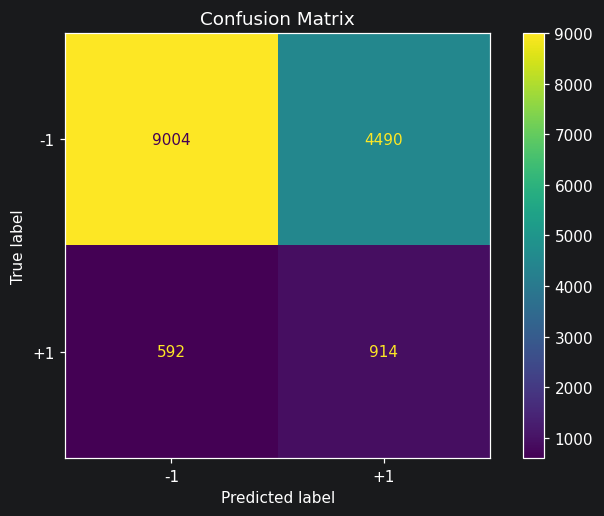

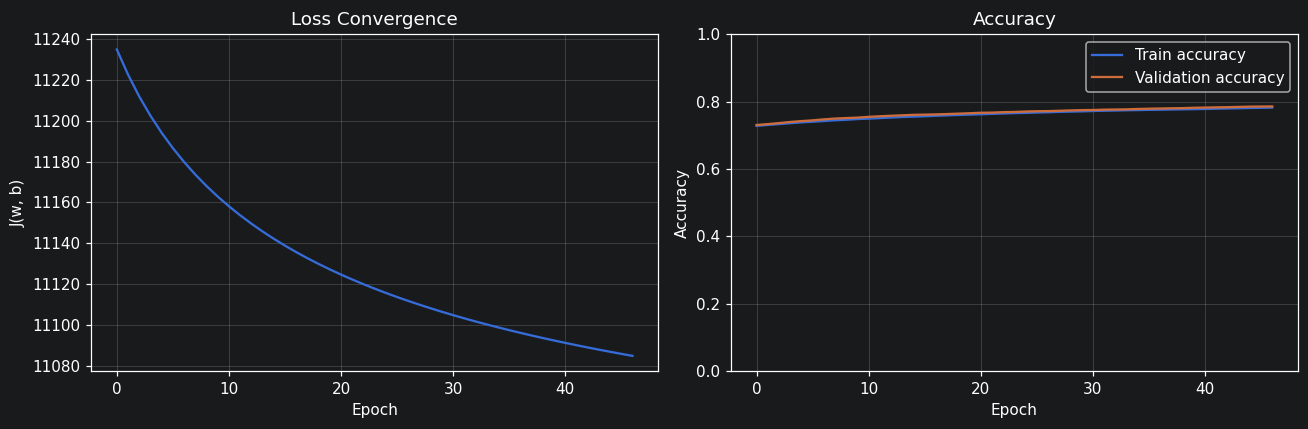

In [13]:
if csv_path.exists():
    _evaluate_and_report(svm, X_test, y_test)
    plot_loss_convergence(svm)

    if X_train.shape[1] == 2:
        plot_decision_boundary_2d(svm, X_train, y_train, title="Decision Boundary (Train set)")
